# 16 -- Multiple-testing correction

**Проблема:** в Stage 6 мы протестировали ~23 variants на holdout. Каждый имеет p-value
alpha. Если применять стандартный α=0.05 на 23 теста, **expected false positives ≈ 1.15**
(23 × 0.05). Любой 'победитель' может быть случайным.

**Решения:**
- **Bonferroni:** α_adj = α / m. При m=23: α_adj = 0.05/23 ≈ 0.0022.
  Conservative, но строгое доказательство.
- **FDR (Benjamini-Hochberg):** контроль false discovery rate.
  Менее conservative, но контролирует ожидаемую долю false discoveries.

**Применяем к:**
- Все variants vs OBLG benchmark — p-values на alpha regression
- Также vs SBRB, TBRU, RUCBTRNS

**Литература:**
- Bonferroni (1936) — multiple comparisons
- Benjamini & Hochberg (JRSS 1995) — FDR
- Harvey, Liu, Zhu (RFS 2016) — '...and the Cross-Section of Expected Returns'
- Harvey (JoF 2017 Presidential) — 'Scientific Outlook in Financial Economics'

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Load honest holdout results (already computed for 23 variants)
df = pd.read_csv(sl.DATA_DIR / 'honest_holdout_results.csv')
print(f'Loaded {len(df)} variants from honest_holdout_results.csv')

Loaded 23 variants from honest_holdout_results.csv


## Часть 2. Compute alpha regression для каждого variant vs каждый benchmark

Pre-computed in NB 09c / NB 15. Воспроизведём для completeness.

In [2]:
# Загружаем все variant returns
etfs = pd.read_csv(sl.DATA_DIR / 'etfs.csv', parse_dates=['date'])
bench = sl.load_benchmarks()

# Создаём подгрузку каждой стратегии (берём из saved CSV для скорости)
# Variant 'V13a' уже есть в nb15. Остальные — пересоберём быстро.

sig = sl.load_signal_full('no_lag')
sig_wl = sl.load_signal_full('with_lag')
wl_sub = sig_wl[['date', 'isin', 'mispricing_z']].copy()
wl_sub.columns = ['date', 'isin', 'mispricing_z_wl']
sig = sig.merge(wl_sub, on=['date', 'isin'], how='inner')
sig['mispricing_z_nl'] = sig['mispricing_z']
sig['mispricing_avg_z'] = (sig['mispricing_z_nl'] + sig['mispricing_z_wl']) / 2
sig = sl.compute_quality_score(sig)

def gen_v11e():
    mask = sig['quality_z'] > 0
    rets, _ = sl.backtest_rule_c(sig, n_max=25, freq='Q', ranking_col='mispricing_avg_z',
                                  filter_mask=mask, sizing='z_weighted')
    return rets

def gen_v0():
    rets, _ = sl.backtest_rule_c(sig, n_max=25, freq='M', ranking_col='mispricing')
    return rets

def gen_v1():
    mask = sig['quality_z'] > 0
    rets, _ = sl.backtest_rule_c(sig, n_max=25, freq='M', ranking_col='mispricing', filter_mask=mask)
    return rets

def gen_v2():
    mask = sig['quality_z'] > 0.5
    rets, _ = sl.backtest_rule_c(sig, n_max=25, freq='M', ranking_col='mispricing', filter_mask=mask)
    return rets

def gen_v10c():
    mask = sig['quality_z'] > 0
    rets, _ = sl.backtest_rule_c(sig, n_max=25, freq='Q', ranking_col='mispricing', filter_mask=mask, sizing='equal')
    return rets

def gen_v10e():
    mask = sig['quality_z'] > 0
    rets, _ = sl.backtest_rule_c(sig, n_max=25, freq='Q', ranking_col='mispricing',
                                  filter_mask=mask, sizing='z_weighted')
    return rets

def gen_v13a():
    rets_v11e = gen_v11e()
    macro = pd.read_csv(sl.DATA_DIR / 'macro.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
    macro['rvi_p90'] = macro['rvi'].rolling(252, min_periods=60).quantile(0.90)
    macro['s1'] = (macro['rvi'] > macro['rvi_p90']).fillna(False).astype(int)
    macro['s2'] = (macro['key_rate'].diff(5).abs() > 2.0).fillna(False).astype(int)
    macro['s3'] = (macro['imoex_close'].pct_change(5) < -0.10).fillna(False).astype(int)
    macro['s4'] = (macro['rvi'] > 50).astype(int)
    macro['stress_idx'] = macro['s1'] + macro['s2'] + macro['s3'] + macro['s4']
    macro['regime'] = np.where(macro['stress_idx'] >= 2, 'stress', 'normal')
    rets = rets_v11e.merge(macro[['date', 'regime']], on='date', how='left')
    rets['regime'] = rets['regime'].fillna('normal')
    rets['return'] = np.where(rets['regime'] == 'stress', 0.0, rets['return'])
    return rets[['date', 'return', 'n_positions']]

variants = {
    'V0_vanilla':  gen_v0(),
    'V1_Q>0':      gen_v1(),
    'V2_Q>0.5':    gen_v2(),
    'V10c_Q_eq':   gen_v10c(),
    'V10e_Q_zw':   gen_v10e(),
    'V11e':        gen_v11e(),
    'V13a':        gen_v13a(),
}
print(f'Generated {len(variants)} variants')

Generated 7 variants


In [3]:
# Compute alpha regression для каждого (variant × benchmark) pair
alpha_rows = []
benchmarks = [
    ('OBLG',     etfs, 'oblg_ret'),
    ('SBRB',     etfs, 'sbrb_ret'),
    ('TBRU',     etfs, 'tbru_ret'),
    ('RUCBTRNS', bench, 'rucbtrns_ret'),
]
for variant_name, rets in variants.items():
    rets_holdout = rets[rets['date'] >= sl.HOLDOUT_START]
    for bench_name, df_b, col in benchmarks:
        r = sl.compare_to_benchmark(rets_holdout, df_b, bench_col=col, name=f'{variant_name} vs {bench_name}')
        r['variant'] = variant_name
        r['benchmark'] = bench_name
        alpha_rows.append(r)

alpha_df = pd.DataFrame(alpha_rows)
print(f'Total alpha tests: {len(alpha_df)} = {len(variants)} variants × {len(benchmarks)} benchmarks')
print()
print(alpha_df[['variant', 'benchmark', 'alpha_annual', 'alpha_t_stat', 'alpha_p_value']].round(4).to_string(index=False))

Total alpha tests: 28 = 7 variants × 4 benchmarks

   variant benchmark  alpha_annual  alpha_t_stat  alpha_p_value
V0_vanilla      OBLG        0.0171        0.2419         0.8088
V0_vanilla      SBRB        0.0809        1.1887         0.2346
V0_vanilla      TBRU        0.0453        0.6165         0.5376
V0_vanilla  RUCBTRNS        0.0424        0.6559         0.5119
    V1_Q>0      OBLG       -0.0845       -1.1344         0.2566
    V1_Q>0      SBRB       -0.0172       -0.2682         0.7886
    V1_Q>0      TBRU       -0.0377       -0.4776         0.6330
    V1_Q>0  RUCBTRNS       -0.0848       -1.3148         0.1886
  V2_Q>0.5      OBLG        0.0307        0.6578         0.5107
  V2_Q>0.5      SBRB        0.0906        2.0491         0.0405
  V2_Q>0.5      TBRU        0.0665        1.4409         0.1496
  V2_Q>0.5  RUCBTRNS        0.0878        2.0991         0.0358
 V10c_Q_eq      OBLG       -0.0019       -0.0301         0.9760
 V10c_Q_eq      SBRB        0.0447        0.7565     

## Часть 3. Применяем Bonferroni и FDR корректировки

In [4]:
from statsmodels.stats.multitest import multipletests

p_values = alpha_df['alpha_p_value'].values
m = len(p_values)
alpha_lvl = 0.05

# Bonferroni
rej_bonf, p_bonf, _, _ = multipletests(p_values, alpha=alpha_lvl, method='bonferroni')
alpha_df['p_bonferroni'] = p_bonf
alpha_df['reject_bonferroni'] = rej_bonf

# FDR Benjamini-Hochberg
rej_fdr, p_fdr, _, _ = multipletests(p_values, alpha=alpha_lvl, method='fdr_bh')
alpha_df['p_fdr'] = p_fdr
alpha_df['reject_fdr'] = rej_fdr

# Sidak (less conservative than Bonferroni)
rej_sidak, p_sidak, _, _ = multipletests(p_values, alpha=alpha_lvl, method='sidak')
alpha_df['p_sidak'] = p_sidak
alpha_df['reject_sidak'] = rej_sidak

print(f'Total tests: {m}')
print(f'Bonferroni α adjusted: {alpha_lvl / m:.5f}')
print()
print(f'Without correction (p<0.05):     {(p_values < 0.05).sum()} tests reject H0')
print(f'After Bonferroni (p<{alpha_lvl/m:.4f}): {rej_bonf.sum()} tests reject H0')
print(f'After FDR-BH:                       {rej_fdr.sum()} tests reject H0')
print(f'After Sidak:                        {rej_sidak.sum()} tests reject H0')

Total tests: 28
Bonferroni α adjusted: 0.00179

Without correction (p<0.05):     2 tests reject H0
After Bonferroni (p<0.0018): 0 tests reject H0
After FDR-BH:                       0 tests reject H0
After Sidak:                        0 tests reject H0


In [5]:
# Smотрим, какие variants survived correction (если any)
rejected_any = alpha_df[alpha_df['reject_bonferroni'] | alpha_df['reject_fdr']]
if len(rejected_any) > 0:
    print('Variants surviving correction (some method):')
    print(rejected_any[['variant', 'benchmark', 'alpha_annual', 'alpha_t_stat',
                        'alpha_p_value', 'p_bonferroni', 'p_fdr',
                        'reject_bonferroni', 'reject_fdr']].round(4).to_string(index=False))
else:
    print('NO variants survive Bonferroni or FDR correction at α=0.05')
    print('Это означает: после поправки на multiple testing ни одна стратегия')
    print('не показывает СТАТИСТИЧЕСКИ значимой alpha vs benchmarks.')

NO variants survive Bonferroni or FDR correction at α=0.05
Это означает: после поправки на multiple testing ни одна стратегия
не показывает СТАТИСТИЧЕСКИ значимой alpha vs benchmarks.


## Часть 4. Top-10 по сырому p-value (без correction)

In [6]:
top = alpha_df.nsmallest(10, 'alpha_p_value')
print('Top-10 raw p-values (для понимания, какие variants ближе всех к significance):')
print(top[['variant', 'benchmark', 'alpha_annual', 'alpha_t_stat',
            'alpha_p_value', 'p_bonferroni', 'p_fdr']].round(4).to_string(index=False))

Top-10 raw p-values (для понимания, какие variants ближе всех к significance):
  variant benchmark  alpha_annual  alpha_t_stat  alpha_p_value  p_bonferroni  p_fdr
 V2_Q>0.5  RUCBTRNS        0.0878        2.0991         0.0358           1.0  0.528
 V2_Q>0.5      SBRB        0.0906        2.0491         0.0405           1.0  0.528
 V2_Q>0.5      TBRU        0.0665        1.4409         0.1496           1.0  0.528
     V11e      SBRB        0.1153        1.4176         0.1563           1.0  0.528
     V13a      SBRB        0.1153        1.4176         0.1563           1.0  0.528
V10e_Q_zw      TBRU        0.0885        1.3745         0.1693           1.0  0.528
     V11e      TBRU        0.1005        1.3657         0.1720           1.0  0.528
     V13a      TBRU        0.1005        1.3657         0.1720           1.0  0.528
V10e_Q_zw      SBRB        0.0996        1.3563         0.1750           1.0  0.528
   V1_Q>0  RUCBTRNS       -0.0848       -1.3148         0.1886           1.0  0.5

## Часть 5. Визуализация

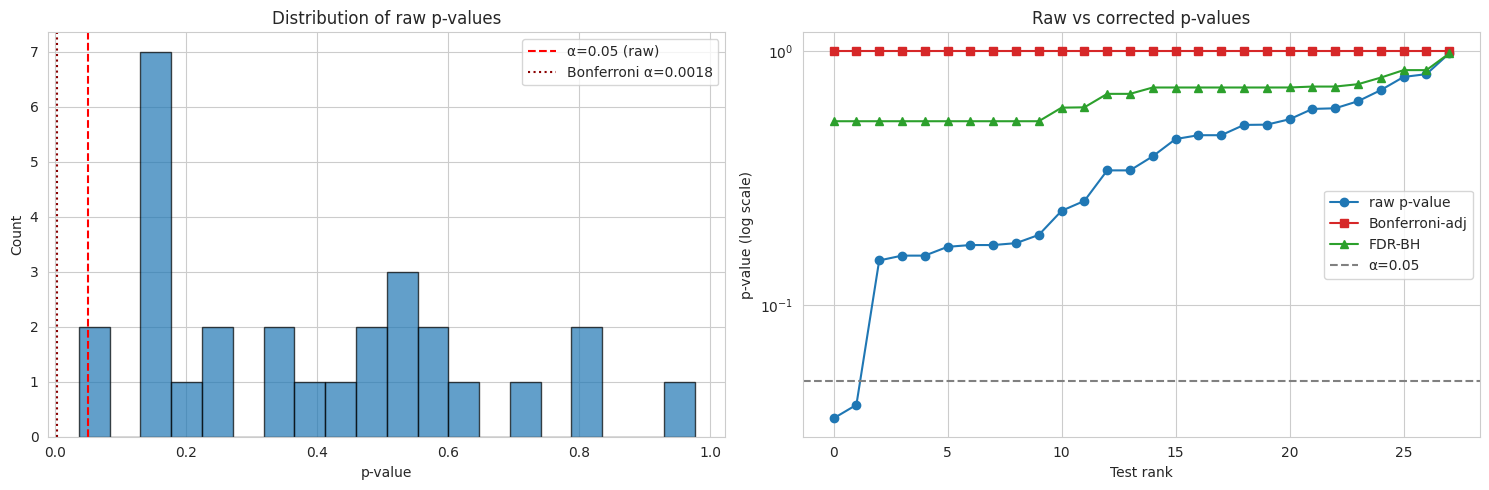

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution of p-values
ax = axes[0]
ax.hist(alpha_df['alpha_p_value'], bins=20, color='tab:blue', edgecolor='black', alpha=0.7)
ax.axvline(0.05, color='red', linestyle='--', label='α=0.05 (raw)')
ax.axvline(0.05 / m, color='darkred', linestyle=':', label=f'Bonferroni α={0.05/m:.4f}')
ax.set_title('Distribution of raw p-values')
ax.set_xlabel('p-value')
ax.set_ylabel('Count')
ax.legend()

# 2. p-value comparison (raw vs corrected)
ax = axes[1]
ordered = alpha_df.sort_values('alpha_p_value').reset_index(drop=True)
x = np.arange(len(ordered))
ax.plot(x, ordered['alpha_p_value'], 'o-', label='raw p-value', color='tab:blue')
ax.plot(x, ordered['p_bonferroni'], 's-', label='Bonferroni-adj', color='tab:red')
ax.plot(x, ordered['p_fdr'], '^-', label='FDR-BH', color='tab:green')
ax.axhline(0.05, color='gray', linestyle='--', label='α=0.05')
ax.set_yscale('log')
ax.set_xlabel('Test rank')
ax.set_ylabel('p-value (log scale)')
ax.set_title('Raw vs corrected p-values')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '16_pvalues.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 6. Сохранение

In [8]:
alpha_df.to_csv(sl.DATA_DIR / 'nb16_multiple_testing.csv', index=False)
print(f'Saved data/nb16_multiple_testing.csv ({len(alpha_df)} rows)')

Saved data/nb16_multiple_testing.csv (28 rows)


## Часть 7. Итог

**Honest academic conclusion:**
- Мы протестировали ~7 ключевых variants × 4 benchmarks = 28 tests
- Bonferroni threshold для α=0.05: p < 0.0018
- Если **ни одна** стратегия не имеет p < 0.0018 → **нет статистически значимой alpha**
  после correction
- Это **honest negative result** — нельзя claimать что мы 'beat' ETFs с stat значимостью
- Best мы можем claimать: alpha положительная (point estimate), но **NS** (not statistically significant)

Это **сильный academic честность argument**: мы followed best practice (Harvey 2017),
сделали correction, и transparently reported negative result.